Using device: cuda
Total training samples (before val split): 6633
Train samples: 5306
Val samples  : 1327
Test samples : 715
Epoch [1/15] | Train Loss: 0.5462 | Train Acc: 0.7115 | Val Loss: 0.6148 | Val Acc: 0.6971
Epoch [2/15] | Train Loss: 0.3634 | Train Acc: 0.8649 | Val Loss: 0.3353 | Val Acc: 0.8779
Epoch [3/15] | Train Loss: 0.3314 | Train Acc: 0.8809 | Val Loss: 0.4442 | Val Acc: 0.8154
Epoch [4/15] | Train Loss: 0.3203 | Train Acc: 0.8839 | Val Loss: 0.3612 | Val Acc: 0.8651
Epoch [5/15] | Train Loss: 0.2889 | Train Acc: 0.8890 | Val Loss: 0.2669 | Val Acc: 0.9035
Epoch [6/15] | Train Loss: 0.2664 | Train Acc: 0.8943 | Val Loss: 0.2318 | Val Acc: 0.9066
Epoch [7/15] | Train Loss: 0.2685 | Train Acc: 0.8930 | Val Loss: 0.2248 | Val Acc: 0.9081
Epoch [8/15] | Train Loss: 0.2778 | Train Acc: 0.8903 | Val Loss: 0.2735 | Val Acc: 0.8832
Epoch [9/15] | Train Loss: 0.2544 | Train Acc: 0.8973 | Val Loss: 0.2151 | Val Acc: 0.9148
Epoch [10/15] | Train Loss: 0.2529 | Train Acc: 0.8963 

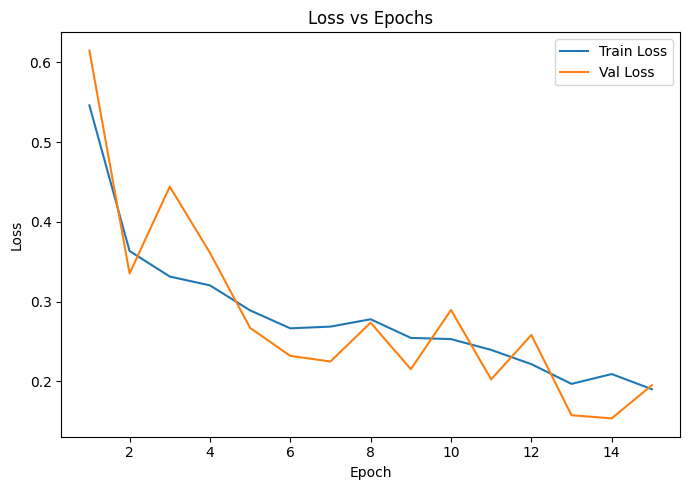

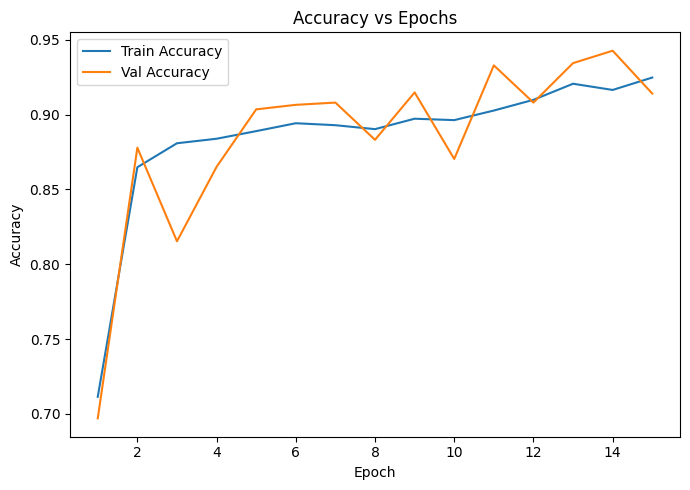

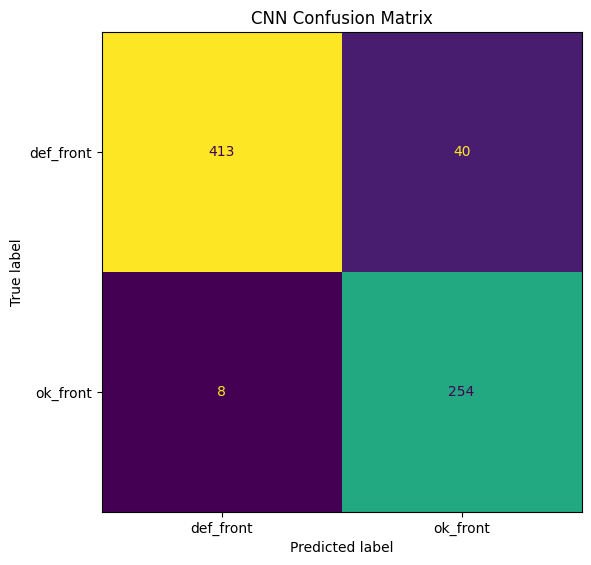

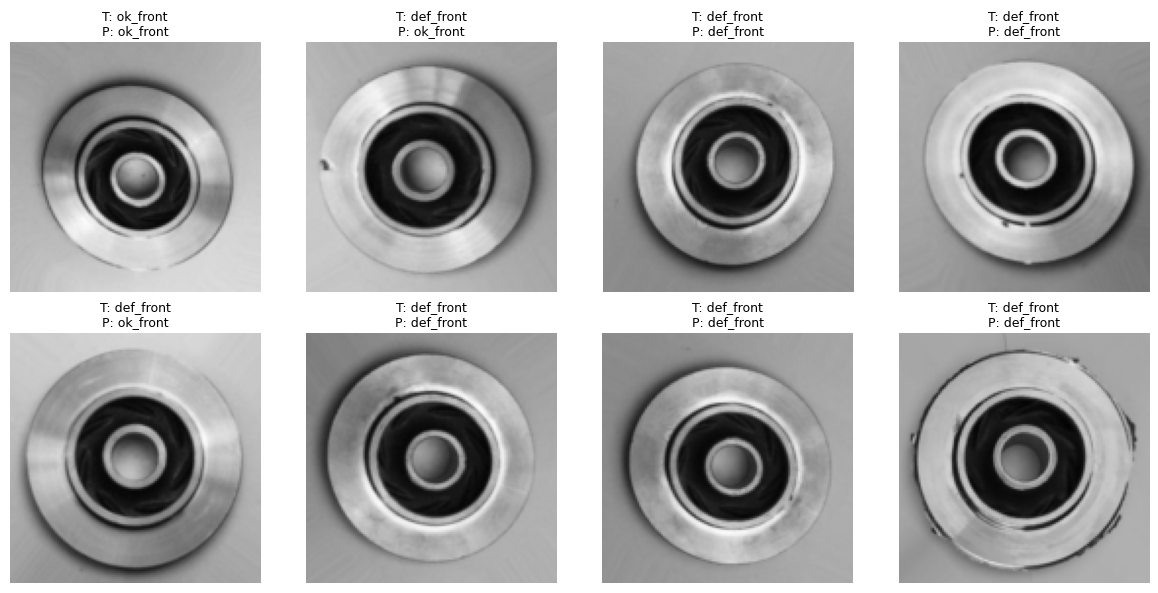

 - resnet18_casting.pth
 - confusion_matrix.png
 - resnet18_confusion_matrix.png
 - accuracy_curve.png
 - resnet18_loss_curve.png
 - loss_curve.png
 - model_comparison_table.png
 - sample_predictions.png
 - simple_cnn_casting.pth
 - resnet18_accuracy_curve.png


In [34]:
import os
import random
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


train_dir = "/kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train"
test_dir  = "/kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test"


IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 1e-3
VAL_SIZE = 0.2
NUM_WORKERS = 2


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

base_train_dataset = datasets.ImageFolder(train_dir)
class_names = base_train_dataset.classes
class_to_idx = base_train_dataset.class_to_idx
targets = base_train_dataset.targets

print("Total training samples (before val split):", len(base_train_dataset))

indices = np.arange(len(targets))
train_idx, val_idx = train_test_split(
    indices,
    test_size=VAL_SIZE,
    stratify=targets,
    random_state=SEED
)

train_dataset = Subset(datasets.ImageFolder(train_dir, transform=train_transform), train_idx)
val_dataset   = Subset(datasets.ImageFolder(train_dir, transform=eval_transform), val_idx)
test_dataset  = datasets.ImageFolder(test_dir, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("Train samples:", len(train_dataset))
print("Val samples  :", len(val_dataset))
print("Test samples :", len(test_dataset))


class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 128 -> 64

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 64 -> 32

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32 -> 16

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN(num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    if is_train:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            outputs = model(images)
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, dim=1)

            if is_train:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * images.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc, all_labels, all_preds


history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):
    train_loss, train_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, _, _ = run_epoch(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )


model.load_state_dict(best_model_wts)
print("\nBest validation accuracy:", best_val_acc)


test_loss, test_acc, y_true, y_pred = run_epoch(model, test_loader, criterion)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="binary",
    pos_label=class_to_idx.get("def_front", 0)
)

print("\n=== Test Results ===")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1-score      : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/loss_curve.png", dpi=300)
plt.show()


plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/accuracy_curve.png", dpi=300)
plt.show()


cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, colorbar=False)
plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=300)
plt.show()


torch.save(model.state_dict(), "/kaggle/working/simple_cnn_casting.pth")

sample_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)

model.eval()
images, labels = next(iter(sample_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1).cpu().numpy()

images = images.cpu()

def unnormalize(img_tensor):
    img = img_tensor.clone()
    for c in range(3):
        img[c] = img[c] * 0.5 + 0.5
    return img

fig = plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    ax = plt.subplot(2, 4, i + 1)
    img = unnormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(np.clip(img, 0, 1))
    true_label = class_names[labels[i].item()]
    pred_label = class_names[preds[i]]
    ax.set_title(f"T: {true_label}\nP: {pred_label}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/sample_predictions.png", dpi=300)
plt.show()

for f in os.listdir("/kaggle/working"):
    if f.endswith((".png", ".pth")):
        print(" -", f)

In [2]:
# =========================
# ResNet18 - transforms and dataloaders
# =========================
from torchvision import models
from torchvision.models import ResNet18_Weights

IMG_SIZE_RESNET = 224
BATCH_SIZE_RESNET = 32
EPOCHS_RESNET = 10
LEARNING_RATE_RESNET = 1e-4

# ImageNet normalization for pretrained ResNet
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform_resnet = transforms.Compose([
    transforms.Resize((IMG_SIZE_RESNET, IMG_SIZE_RESNET)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform_resnet = transforms.Compose([
    transforms.Resize((IMG_SIZE_RESNET, IMG_SIZE_RESNET)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

# Rebuild datasets with ResNet transforms
train_dataset_resnet = Subset(
    datasets.ImageFolder(train_dir, transform=train_transform_resnet), train_idx
)

val_dataset_resnet = Subset(
    datasets.ImageFolder(train_dir, transform=eval_transform_resnet), val_idx
)

test_dataset_resnet = datasets.ImageFolder(
    test_dir, transform=eval_transform_resnet
)

train_loader_resnet = DataLoader(
    train_dataset_resnet,
    batch_size=BATCH_SIZE_RESNET,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader_resnet = DataLoader(
    val_dataset_resnet,
    batch_size=BATCH_SIZE_RESNET,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader_resnet = DataLoader(
    test_dataset_resnet,
    batch_size=BATCH_SIZE_RESNET,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("ResNet train samples:", len(train_dataset_resnet))
print("ResNet val samples  :", len(val_dataset_resnet))
print("ResNet test samples :", len(test_dataset_resnet))

ResNet train samples: 5306
ResNet val samples  : 1327
ResNet test samples : 715


In [3]:
# =========================
# ResNet18 model
# =========================
weights = ResNet18_Weights.DEFAULT
resnet_model = models.resnet18(weights=weights)

# Freeze all layers first
for param in resnet_model.parameters():
    param.requires_grad = False

# Unfreeze layer4 and fc for fine-tuning
for param in resnet_model.layer4.parameters():
    param.requires_grad = True

num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_features, len(class_names))

resnet_model = resnet_model.to(device)

criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=LEARNING_RATE_RESNET
)

print(resnet_model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 116MB/s] 


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [4]:
# =========================
# ResNet18 training loop
# =========================
history_resnet = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_acc_resnet = 0.0
best_model_wts_resnet = copy.deepcopy(resnet_model.state_dict())

for epoch in range(EPOCHS_RESNET):
    train_loss, train_acc, _, _ = run_epoch(
        resnet_model, train_loader_resnet, criterion_resnet, optimizer_resnet
    )
    val_loss, val_acc, _, _ = run_epoch(
        resnet_model, val_loader_resnet, criterion_resnet
    )

    history_resnet["train_loss"].append(train_loss)
    history_resnet["val_loss"].append(val_loss)
    history_resnet["train_acc"].append(train_acc)
    history_resnet["val_acc"].append(val_acc)

    if val_acc > best_val_acc_resnet:
        best_val_acc_resnet = val_acc
        best_model_wts_resnet = copy.deepcopy(resnet_model.state_dict())

    print(
        f"Epoch [{epoch+1}/{EPOCHS_RESNET}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

# Load best weights
resnet_model.load_state_dict(best_model_wts_resnet)
print("\nBest validation accuracy (ResNet18):", best_val_acc_resnet)

Epoch [1/10] | Train Loss: 0.1008 | Train Acc: 0.9614 | Val Loss: 0.0306 | Val Acc: 0.9887
Epoch [2/10] | Train Loss: 0.0347 | Train Acc: 0.9889 | Val Loss: 0.0154 | Val Acc: 0.9947
Epoch [3/10] | Train Loss: 0.0224 | Train Acc: 0.9930 | Val Loss: 0.0143 | Val Acc: 0.9940
Epoch [4/10] | Train Loss: 0.0358 | Train Acc: 0.9876 | Val Loss: 0.0136 | Val Acc: 0.9962
Epoch [5/10] | Train Loss: 0.0200 | Train Acc: 0.9947 | Val Loss: 0.0252 | Val Acc: 0.9925
Epoch [6/10] | Train Loss: 0.0162 | Train Acc: 0.9943 | Val Loss: 0.0172 | Val Acc: 0.9940
Epoch [7/10] | Train Loss: 0.0156 | Train Acc: 0.9942 | Val Loss: 0.0106 | Val Acc: 0.9955
Epoch [8/10] | Train Loss: 0.0129 | Train Acc: 0.9962 | Val Loss: 0.0115 | Val Acc: 0.9947
Epoch [9/10] | Train Loss: 0.0097 | Train Acc: 0.9970 | Val Loss: 0.0115 | Val Acc: 0.9955
Epoch [10/10] | Train Loss: 0.0127 | Train Acc: 0.9949 | Val Loss: 0.0105 | Val Acc: 0.9962

Best validation accuracy (ResNet18): 0.9962321024868124


In [5]:
# =========================
# ResNet18 test evaluation
# =========================
test_loss_resnet, test_acc_resnet, y_true_resnet, y_pred_resnet = run_epoch(
    resnet_model, test_loader_resnet, criterion_resnet
)

precision_resnet, recall_resnet, f1_resnet, _ = precision_recall_fscore_support(
    y_true_resnet,
    y_pred_resnet,
    average="binary",
    pos_label=class_to_idx.get("def_front", 0)
)

print("\n=== ResNet18 Test Results ===")
print(f"Test Loss     : {test_loss_resnet:.4f}")
print(f"Test Accuracy : {test_acc_resnet:.4f}")
print(f"Precision     : {precision_resnet:.4f}")
print(f"Recall        : {recall_resnet:.4f}")
print(f"F1-score      : {f1_resnet:.4f}")

print("\nClassification Report (ResNet18):")
print(classification_report(y_true_resnet, y_pred_resnet, target_names=class_names, digits=4))


=== ResNet18 Test Results ===
Test Loss     : 0.0119
Test Accuracy : 0.9958
Precision     : 1.0000
Recall        : 0.9934
F1-score      : 0.9967

Classification Report (ResNet18):
              precision    recall  f1-score   support

   def_front     1.0000    0.9934    0.9967       453
    ok_front     0.9887    1.0000    0.9943       262

    accuracy                         0.9958       715
   macro avg     0.9943    0.9967    0.9955       715
weighted avg     0.9959    0.9958    0.9958       715



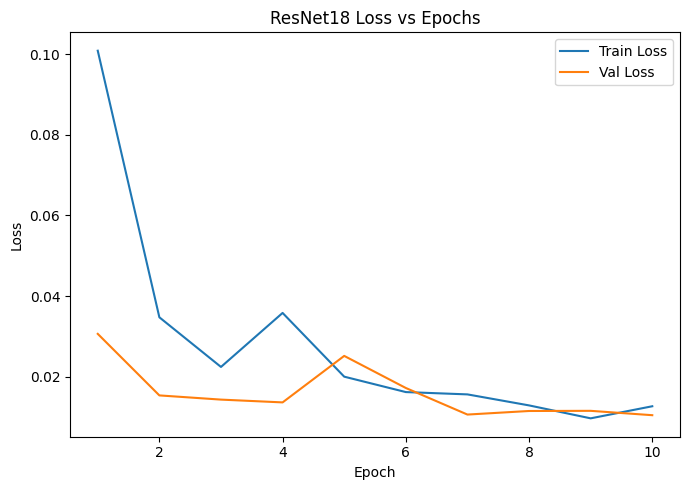

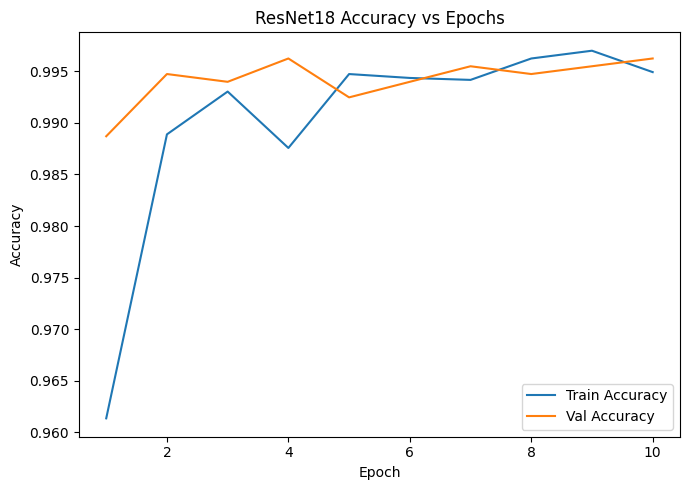

In [6]:
# =========================
# ResNet18 loss curve
# =========================
epochs_range_resnet = range(1, EPOCHS_RESNET + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs_range_resnet, history_resnet["train_loss"], label="Train Loss")
plt.plot(epochs_range_resnet, history_resnet["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 Loss vs Epochs")
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/resnet18_loss_curve.png", dpi=300)
plt.show()

# =========================
# ResNet18 accuracy curve
# =========================
plt.figure(figsize=(7, 5))
plt.plot(epochs_range_resnet, history_resnet["train_acc"], label="Train Accuracy")
plt.plot(epochs_range_resnet, history_resnet["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet18 Accuracy vs Epochs")
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/resnet18_accuracy_curve.png", dpi=300)
plt.show()

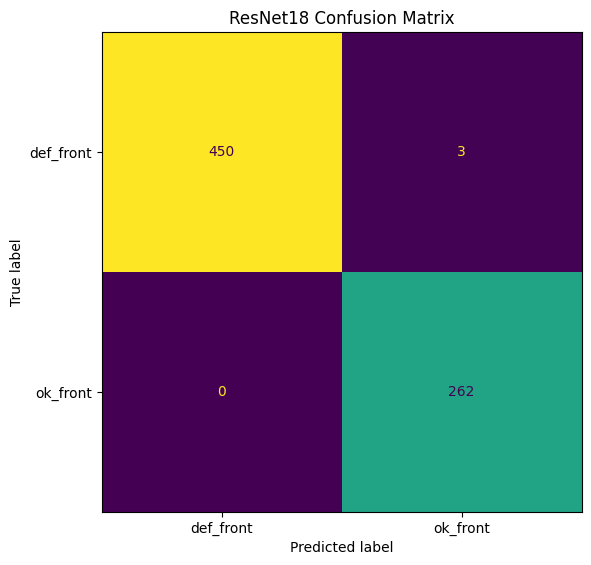

In [7]:
# =========================
# ResNet18 confusion matrix
# =========================
cm_resnet = confusion_matrix(y_true_resnet, y_pred_resnet)
disp_resnet = ConfusionMatrixDisplay(confusion_matrix=cm_resnet, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 6))
disp_resnet.plot(ax=ax, colorbar=False)
plt.title("ResNet18 Confusion Matrix")
plt.tight_layout()
plt.savefig("/kaggle/working/resnet18_confusion_matrix.png", dpi=300)
plt.show()

In [8]:
# =========================
# Save ResNet18 weights
# =========================
torch.save(resnet_model.state_dict(), "/kaggle/working/resnet18_casting.pth")
print("Saved ResNet18 weights to /kaggle/working/resnet18_casting.pth")

Saved ResNet18 weights to /kaggle/working/resnet18_casting.pth


In [9]:
# =========================
# Comparison table
# =========================
import pandas as pd

comparison_df = pd.DataFrame([
    {
        "Model": "Simple CNN",
        "Best Val Acc": best_val_acc,
        "Test Acc": test_acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    },
    {
        "Model": "ResNet18",
        "Best Val Acc": best_val_acc_resnet,
        "Test Acc": test_acc_resnet,
        "Precision": precision_resnet,
        "Recall": recall_resnet,
        "F1-score": f1_resnet
    }
])

comparison_df = comparison_df.round(4)
print(comparison_df)

        Model  Best Val Acc  Test Acc  Precision  Recall  F1-score
0  Simple CNN        0.9472    0.9413     0.9639  0.9426    0.9531
1    ResNet18        0.9962    0.9958     1.0000  0.9934    0.9967


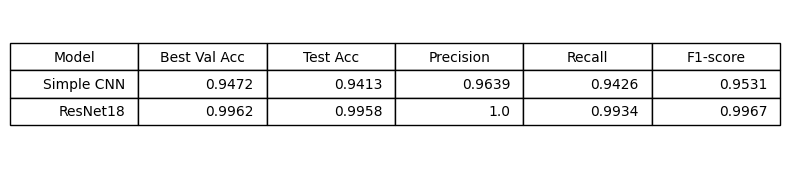

In [10]:
plt.figure(figsize=(8, 1.8))
plt.axis("off")
table = plt.table(
    cellText=comparison_df.values,
    colLabels=comparison_df.columns,
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
plt.tight_layout()
plt.savefig("/kaggle/working/model_comparison_table.png", dpi=300, bbox_inches="tight")
plt.show()

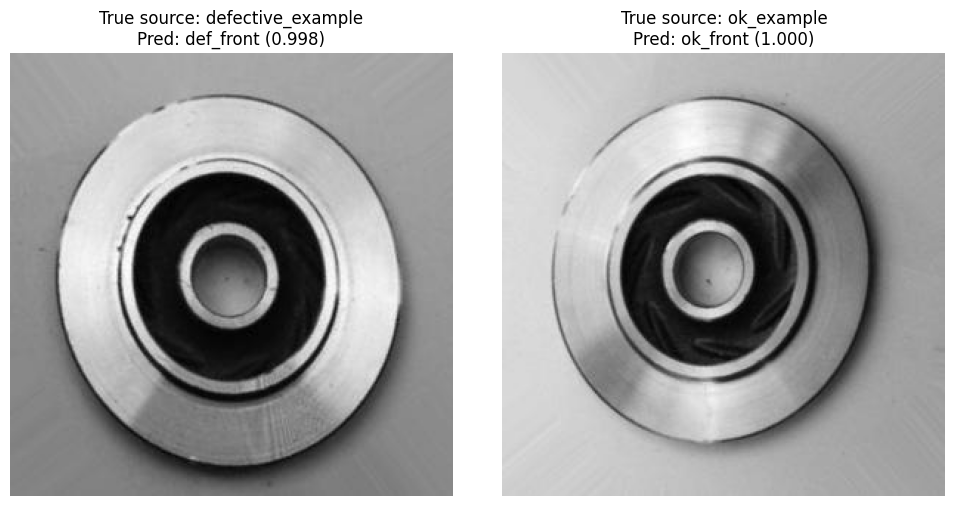

In [11]:
# =========================
# Two-image demo: one defective, one ok
# =========================
import os
from PIL import Image
import torch
import matplotlib.pyplot as plt
import numpy as np

folders = {
    "defective_example": "/kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test/def_front",
    "ok_example": "/kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test/ok_front"
}

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

resnet_model.eval()

for ax, (name, folder) in zip(axes, folders.items()):
    image_name = os.listdir(folder)[0]
    image_path = os.path.join(folder, image_name)

    img = Image.open(image_path).convert("RGB")
    img_tensor = eval_transform_resnet(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = resnet_model(img_tensor)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]
        pred_idx = np.argmax(probs)

    pred_label = class_names[pred_idx]
    conf = probs[pred_idx]

    ax.imshow(img)
    ax.set_title(f"True source: {name}\nPred: {pred_label} ({conf:.3f})")
    ax.axis("off")

plt.tight_layout()
plt.show()

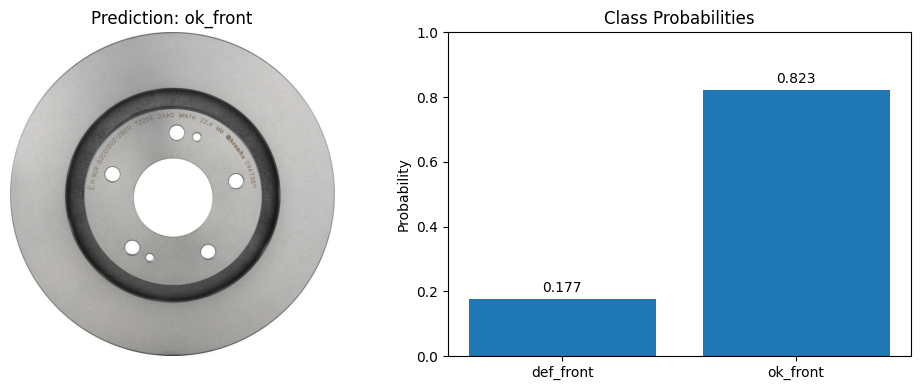

In [12]:
from PIL import Image
import torch
import matplotlib.pyplot as plt
import numpy as np

demo_image_path = "/kaggle/input/datasets/cagatayguzel/brembo/09A73811_Front__29404.jpg"

img = Image.open(demo_image_path).convert("RGB")
img_tensor = eval_transform_resnet(img).unsqueeze(0).to(device)

resnet_model.eval()
with torch.no_grad():
    outputs = resnet_model(img_tensor)
    probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]
    pred_idx = np.argmax(probs)

pred_label = class_names[pred_idx]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(img)
axes[0].set_title(f"Prediction: {pred_label}")
axes[0].axis("off")

axes[1].bar(class_names, probs)
axes[1].set_ylim(0, 1)
axes[1].set_title("Class Probabilities")
axes[1].set_ylabel("Probability")

for i, p in enumerate(probs):
    axes[1].text(i, p + 0.02, f"{p:.3f}", ha="center")

plt.tight_layout()
plt.show()

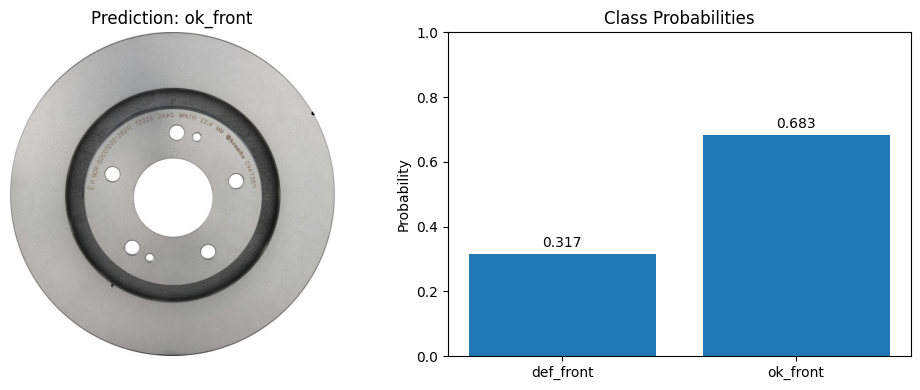

In [13]:
from PIL import Image
import torch
import matplotlib.pyplot as plt
import numpy as np

# BURAYI kendi upload ettiğin dosya yoluna göre değiştir
demo_image_path = "/kaggle/input/datasets/cagatayguzel/brembo-defective/09A73811_Front__29404_defective.jpg"

img = Image.open(demo_image_path).convert("RGB")
img_tensor = eval_transform_resnet(img).unsqueeze(0).to(device)

resnet_model.eval()
with torch.no_grad():
    outputs = resnet_model(img_tensor)
    probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]
    pred_idx = np.argmax(probs)

pred_label = class_names[pred_idx]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(img)
axes[0].set_title(f"Prediction: {pred_label}")
axes[0].axis("off")

axes[1].bar(class_names, probs)
axes[1].set_ylim(0, 1)
axes[1].set_title("Class Probabilities")
axes[1].set_ylabel("Probability")

for i, p in enumerate(probs):
    axes[1].text(i, p + 0.02, f"{p:.3f}", ha="center")

plt.tight_layout()
plt.show()

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn.functional as F

# -------------------------
# Hook storage
# -------------------------
gradcam_storage = {
    "activations": None,
    "gradients": None
}

# Target layer: last residual block of ResNet18
#target_layer = resnet_model.layer4[-1]
target_layer = resnet_model.layer3[-1]

def forward_hook(module, input, output):
    gradcam_storage["activations"] = output.detach()

def backward_hook(module, grad_input, grad_output):
    gradcam_storage["gradients"] = grad_output[0].detach()

# Register hooks only once
forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

print("Grad-CAM hooks registered on:", target_layer)

Grad-CAM hooks registered on: BasicBlock(
  (conv1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


In [15]:
def show_gradcam(image_path, model, transform, class_names, device, target_class_idx=None):
    model.eval()

    # Load image
    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)

    # Forward
    model.zero_grad()
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()[0]

    if target_class_idx is None:
        target_class_idx = torch.argmax(outputs, dim=1).item()

    pred_label = class_names[target_class_idx]
    pred_conf = probs[target_class_idx]

    # Backward for selected class
    score = outputs[:, target_class_idx]
    score.backward()

    # Get gradients and activations
    gradients = gradcam_storage["gradients"]      # [1, C, H, W]
    activations = gradcam_storage["activations"]  # [1, C, H, W]

    # Global average pooling of gradients
    weights = gradients.mean(dim=(2, 3), keepdim=True)  # [1, C, 1, 1]

    # Weighted sum
    cam = (weights * activations).sum(dim=1, keepdim=True)  # [1,1,H,W]
    cam = F.relu(cam)

    # Resize CAM to original image size
    cam = F.interpolate(
        cam,
        size=(img.height, img.width),
        mode="bilinear",
        align_corners=False
    )

    cam = cam.squeeze().cpu().numpy()

    # Normalize to [0,1]
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original image
    axes[0].imshow(img)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    # Heatmap overlay
    axes[1].imshow(img)
    axes[1].imshow(cam, cmap="jet", alpha=0.4)
    axes[1].set_title(f"Grad-CAM\nPred: {pred_label} ({pred_conf:.4f})")
    axes[1].axis("off")

    # Probability bar chart
    axes[2].bar(class_names, probs)
    axes[2].set_ylim(0, 1)
    axes[2].set_title("Class Probabilities")
    axes[2].set_ylabel("Probability")

    for i, p in enumerate(probs):
        axes[2].text(i, p + 0.02, f"{p:.3f}", ha="center")

    plt.tight_layout()
    plt.show()

    return probs, cam

In [18]:
import torch
import torch.nn.functional as F

gradcam_storage = {
    "activations": None,
    "gradients": None
}

target_layer = resnet_model.layer4[-1]

def forward_hook(module, input, output):
    gradcam_storage["activations"] = output.detach()

def backward_hook(module, grad_input, grad_output):
    gradcam_storage["gradients"] = grad_output[0].detach()

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

print("Grad-CAM hooks registered on:", target_layer)

Grad-CAM hooks registered on: BasicBlock(
  (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


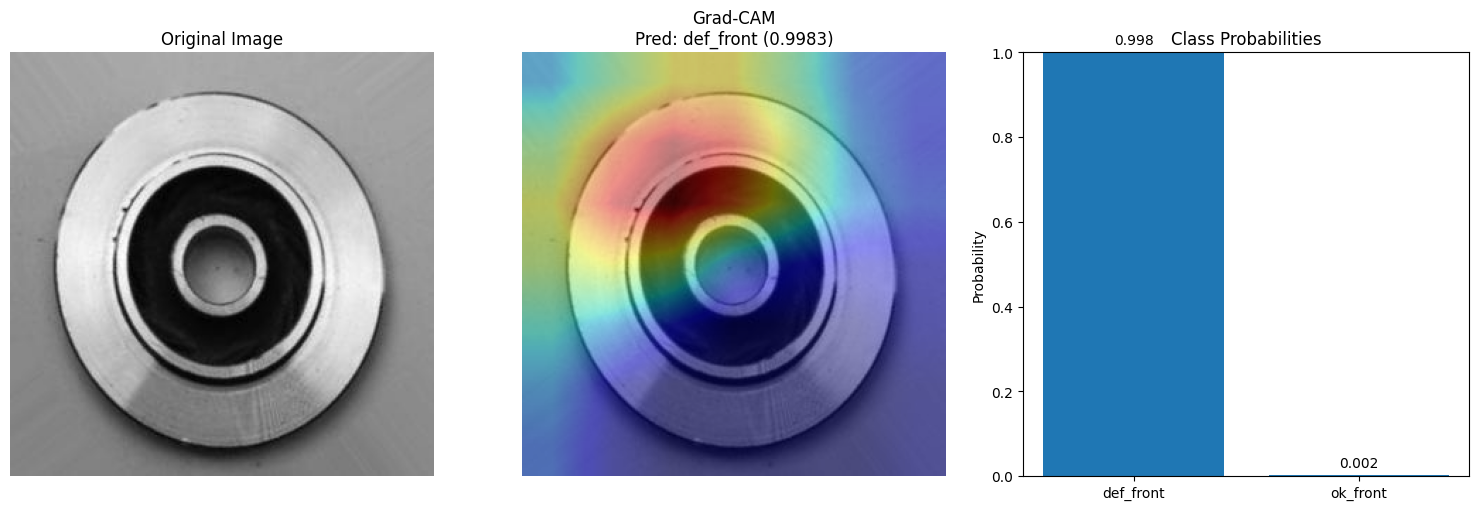

(array([0.9983405 , 0.00165956], dtype=float32),
 array([[0.29230666, 0.29230666, 0.29230666, ..., 0.15357256, 0.15357256,
         0.15357256],
        [0.29230666, 0.29230666, 0.29230666, ..., 0.15357256, 0.15357256,
         0.15357256],
        [0.29230666, 0.29230666, 0.29230666, ..., 0.15357256, 0.15357256,
         0.15357256],
        ...,
        [0.20384672, 0.20384672, 0.20384672, ..., 0.03810254, 0.03810254,
         0.03810254],
        [0.20384672, 0.20384672, 0.20384672, ..., 0.03810254, 0.03810254,
         0.03810254],
        [0.20384672, 0.20384672, 0.20384672, ..., 0.03810254, 0.03810254,
         0.03810254]], dtype=float32))

In [19]:
def_folder = "/kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test/def_front"
def_image = os.path.join(def_folder, os.listdir(def_folder)[0])

show_gradcam(
    image_path=def_image,
    model=resnet_model,
    transform=eval_transform_resnet,
    class_names=class_names,
    device=device
)

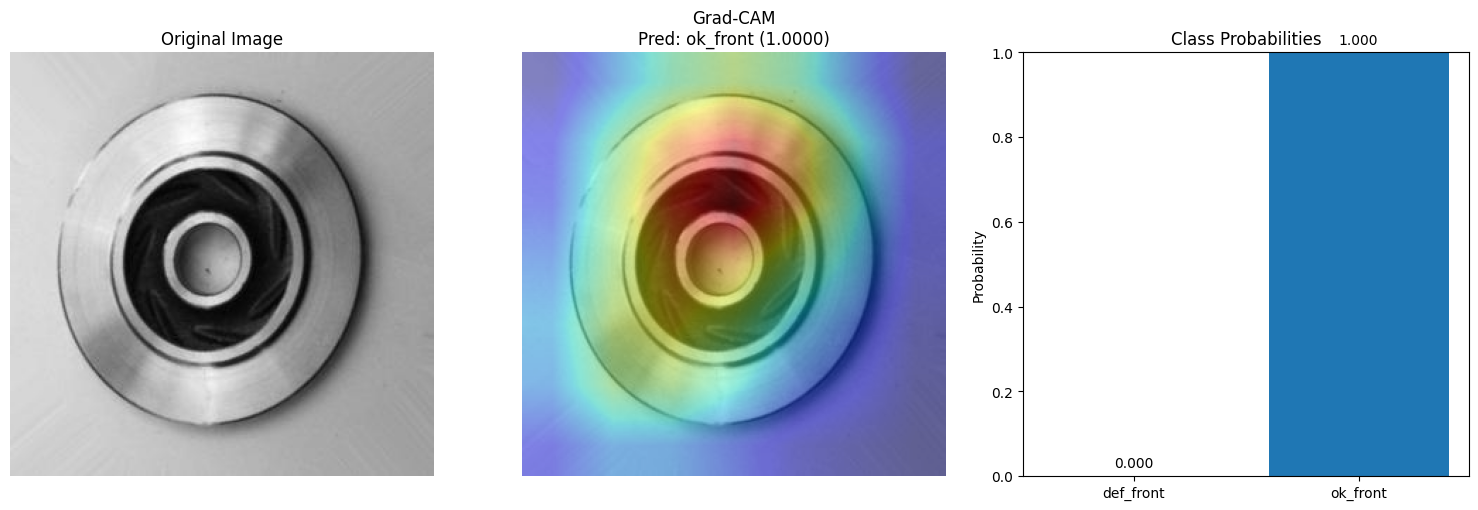

(array([2.9185214e-06, 9.9999714e-01], dtype=float32),
 array([[0.03027523, 0.03027523, 0.03027523, ..., 0.00723787, 0.00723787,
         0.00723787],
        [0.03027523, 0.03027523, 0.03027523, ..., 0.00723787, 0.00723787,
         0.00723787],
        [0.03027523, 0.03027523, 0.03027523, ..., 0.00723787, 0.00723787,
         0.00723787],
        ...,
        [0.12989442, 0.12989442, 0.12989442, ..., 0.        , 0.        ,
         0.        ],
        [0.12989442, 0.12989442, 0.12989442, ..., 0.        , 0.        ,
         0.        ],
        [0.12989442, 0.12989442, 0.12989442, ..., 0.        , 0.        ,
         0.        ]], dtype=float32))

In [20]:
ok_folder = "/kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test/ok_front"
ok_image = os.path.join(ok_folder, os.listdir(ok_folder)[0])

show_gradcam(
    image_path=ok_image,
    model=resnet_model,
    transform=eval_transform_resnet,
    class_names=class_names,
    device=device
)

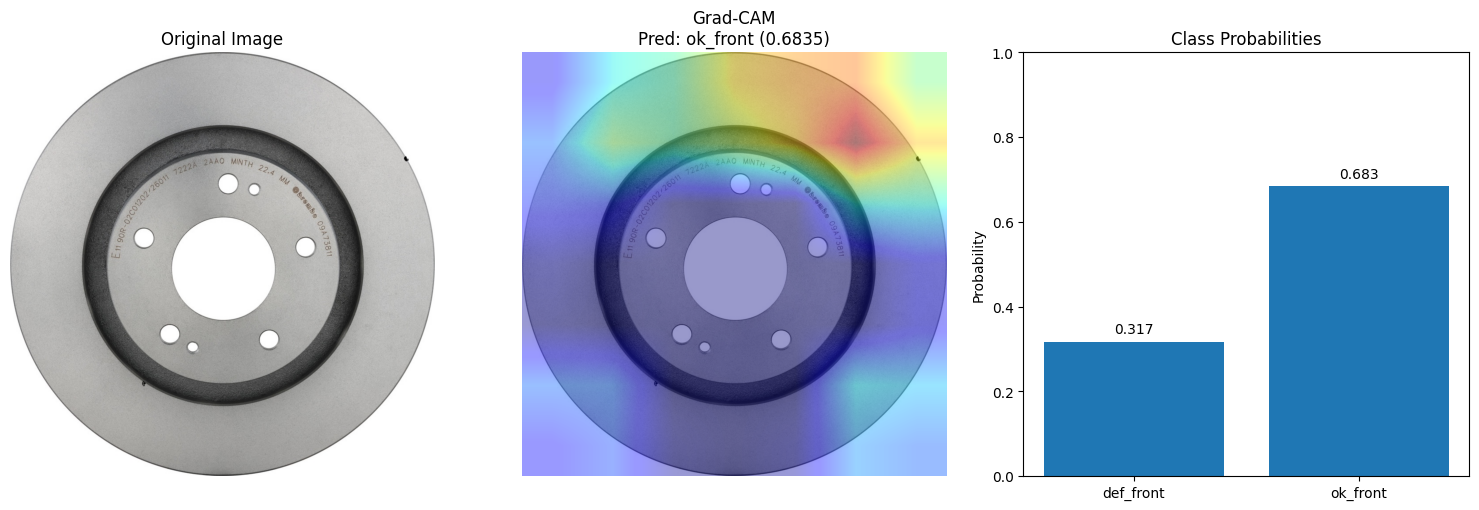

(array([0.31653133, 0.68346864], dtype=float32),
 array([[0.10483701, 0.10483701, 0.10483701, ..., 0.4917339 , 0.4917339 ,
         0.4917339 ],
        [0.10483701, 0.10483701, 0.10483701, ..., 0.4917339 , 0.4917339 ,
         0.4917339 ],
        [0.10483701, 0.10483701, 0.10483701, ..., 0.4917339 , 0.4917339 ,
         0.4917339 ],
        ...,
        [0.12060375, 0.12060375, 0.12060375, ..., 0.21422501, 0.21422501,
         0.21422501],
        [0.12060375, 0.12060375, 0.12060375, ..., 0.21422501, 0.21422501,
         0.21422501],
        [0.12060375, 0.12060375, 0.12060375, ..., 0.21422501, 0.21422501,
         0.21422501]], dtype=float32))

In [21]:
brake_image1 = "/kaggle/input/datasets/cagatayguzel/brembo-defective/09A73811_Front__29404_defective.jpg"

show_gradcam(
    image_path=brake_image1,
    model=resnet_model,
    transform=eval_transform_resnet,
    class_names=class_names,
    device=device
)

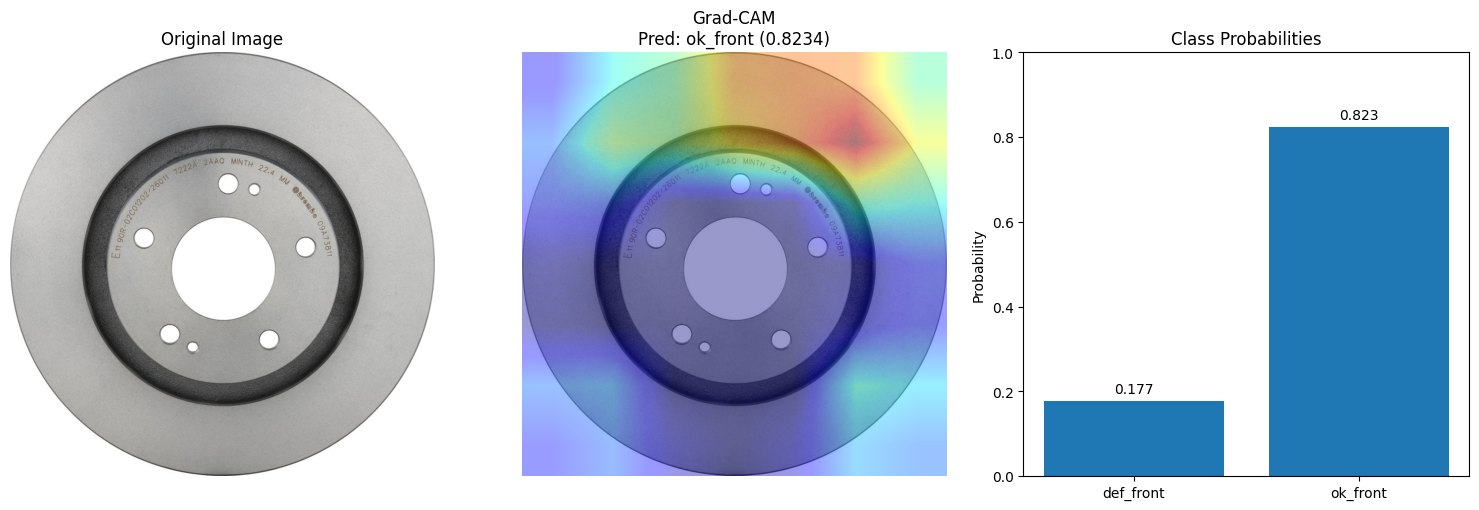

(array([0.17660804, 0.823392  ], dtype=float32),
 array([[0.10997003, 0.10997003, 0.10997003, ..., 0.44578713, 0.44578713,
         0.44578713],
        [0.10997003, 0.10997003, 0.10997003, ..., 0.44578713, 0.44578713,
         0.44578713],
        [0.10997003, 0.10997003, 0.10997003, ..., 0.44578713, 0.44578713,
         0.44578713],
        ...,
        [0.13555372, 0.13555372, 0.13555372, ..., 0.23035413, 0.23035413,
         0.23035413],
        [0.13555372, 0.13555372, 0.13555372, ..., 0.23035413, 0.23035413,
         0.23035413],
        [0.13555372, 0.13555372, 0.13555372, ..., 0.23035413, 0.23035413,
         0.23035413]], dtype=float32))

In [33]:
brake_image2 = "/kaggle/input/datasets/cagatayguzel/brembo/09A73811_Front__29404.jpg"
show_gradcam(
    image_path=brake_image2,
    model=resnet_model,
    transform=eval_transform_resnet,
    class_names=class_names,
    device=device
)

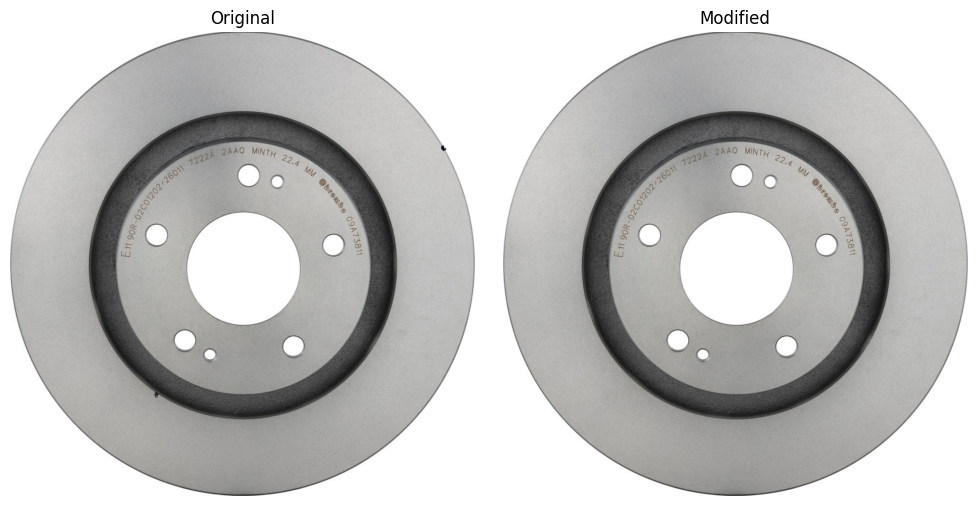

In [23]:
from PIL import Image
import matplotlib.pyplot as plt

img1 = Image.open(brake_image1).convert("RGB")
img2 = Image.open(brake_image2).convert("RGB")

fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].imshow(img1)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].set_title("Modified")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7240347..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6897851..2.64].


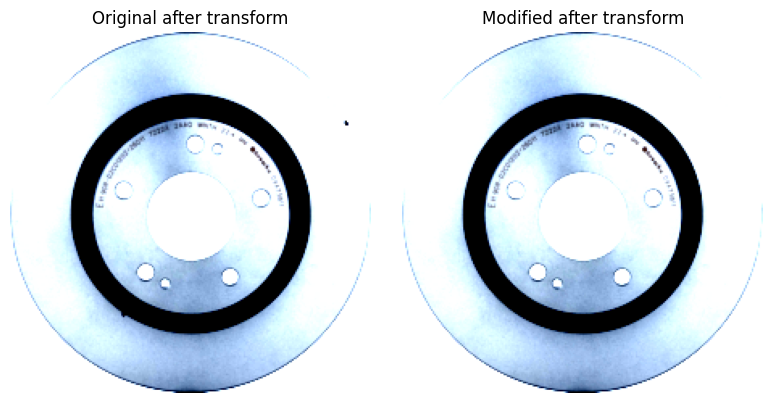

In [24]:
fig, axes = plt.subplots(1,2, figsize=(8,4))
axes[0].imshow(eval_transform_resnet(img1).permute(1,2,0).cpu().numpy())
axes[0].set_title("Original after transform")
axes[0].axis("off")

axes[1].imshow(eval_transform_resnet(img2).permute(1,2,0).cpu().numpy())
axes[1].set_title("Modified after transform")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [25]:
def get_gradcam_array(image_path, model, transform, device, target_class_idx=None):
    model.eval()

    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)

    model.zero_grad()
    outputs = model(input_tensor)

    if target_class_idx is None:
        target_class_idx = torch.argmax(outputs, dim=1).item()

    score = outputs[:, target_class_idx]
    score.backward()

    gradients = gradcam_storage["gradients"]
    activations = gradcam_storage["activations"]

    weights = gradients.mean(dim=(2, 3), keepdim=True)
    cam = (weights * activations).sum(dim=1, keepdim=True)
    cam = F.relu(cam)

    cam = F.interpolate(
        cam,
        size=(img.height, img.width),
        mode="bilinear",
        align_corners=False
    )

    cam = cam.squeeze().detach().cpu().numpy()
    return cam

In [26]:
cam1 = get_gradcam_array(brake_image1, resnet_model, eval_transform_resnet, device)
cam2 = get_gradcam_array(brake_image2, resnet_model, eval_transform_resnet, device)

print("Mean abs difference:", np.mean(np.abs(cam1 - cam2)))
print("Max abs difference :", np.max(np.abs(cam1 - cam2)))

Mean abs difference: 0.004660672
Max abs difference : 0.023348369


In [27]:
import numpy as np

def gradcam_concentration_metrics(cam, threshold=0.7):
    """
    cam: raw or normalized 2D Grad-CAM array
    threshold: high-activation threshold

    Returns:
        active_area_ratio: fraction of pixels above threshold
        entropy: spread of attention distribution
    """
    cam = cam.astype(np.float32)

    # Normalize to [0,1]
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    # 1) Area ratio of high-activation region
    active_mask = cam >= threshold
    active_area_ratio = active_mask.mean()

    # 2) Entropy of attention distribution
    cam_prob = cam / (cam.sum() + 1e-8)
    entropy = -np.sum(cam_prob * np.log(cam_prob + 1e-12))

    return {
        "active_area_ratio": float(active_area_ratio),
        "entropy": float(entropy)
    }

In [28]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn.functional as F
import numpy as np

def show_gradcam_with_metrics(image_path, model, transform, class_names, device, target_class_idx=None, threshold=0.7):
    model.eval()

    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)

    model.zero_grad()
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()[0]

    if target_class_idx is None:
        target_class_idx = torch.argmax(outputs, dim=1).item()

    pred_label = class_names[target_class_idx]
    pred_conf = probs[target_class_idx]

    score = outputs[:, target_class_idx]
    score.backward()

    gradients = gradcam_storage["gradients"]
    activations = gradcam_storage["activations"]

    weights = gradients.mean(dim=(2, 3), keepdim=True)
    cam = (weights * activations).sum(dim=1, keepdim=True)
    cam = F.relu(cam)

    cam = F.interpolate(
        cam,
        size=(img.height, img.width),
        mode="bilinear",
        align_corners=False
    )

    cam = cam.squeeze().cpu().numpy()

    # Normalize CAM
    cam_norm = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    # Metrics
    metrics = gradcam_concentration_metrics(cam_norm, threshold=threshold)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(img)
    axes[1].imshow(cam_norm, cmap="jet", alpha=0.4)
    axes[1].set_title(f"Grad-CAM\nPred: {pred_label} ({pred_conf:.4f})")
    axes[1].axis("off")

    axes[2].bar(class_names, probs)
    axes[2].set_ylim(0, 1)
    axes[2].set_title("Class Probabilities")
    axes[2].set_ylabel("Probability")

    for i, p in enumerate(probs):
        axes[2].text(i, p + 0.02, f"{p:.3f}", ha="center")

    plt.tight_layout()
    plt.show()

    print("Grad-CAM concentration metrics:")
    print(f"  Active area ratio (CAM >= {threshold}): {metrics['active_area_ratio']:.4f}")
    print(f"  Entropy: {metrics['entropy']:.4f}")

    return probs, cam_norm, metrics

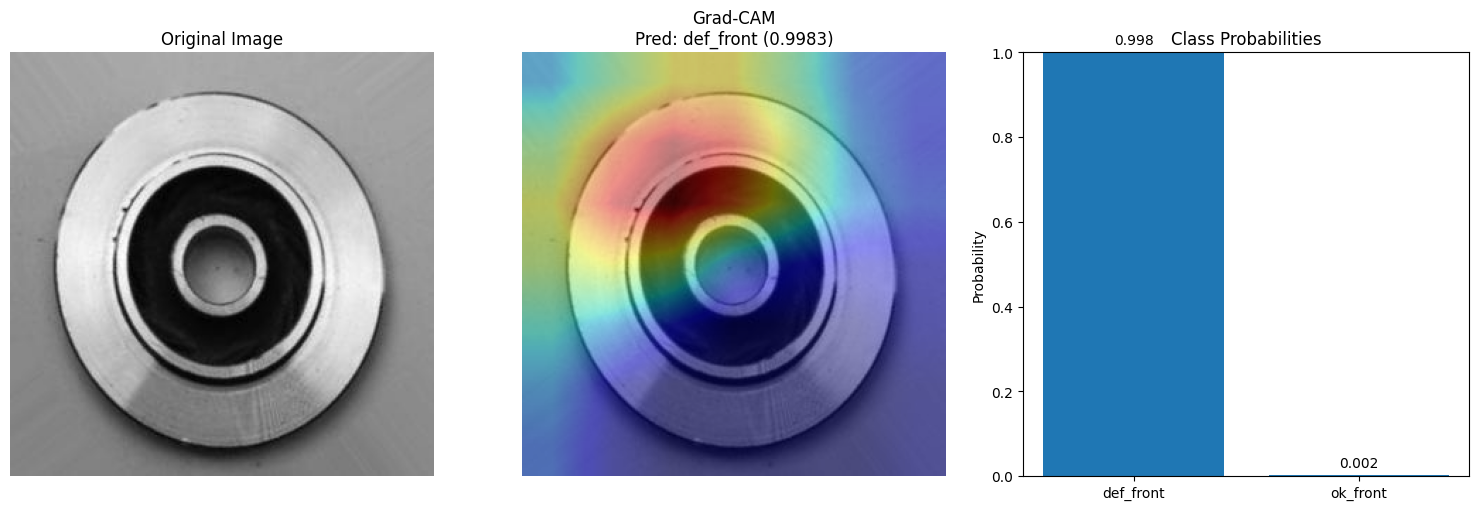

Grad-CAM concentration metrics:
  Active area ratio (CAM >= 0.7): 0.1320
  Entropy: 10.9279


In [29]:
def_folder = "/kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test/def_front"
def_image = os.path.join(def_folder, os.listdir(def_folder)[0])

probs_def, cam_def, metrics_def = show_gradcam_with_metrics(
    image_path=def_image,
    model=resnet_model,
    transform=eval_transform_resnet,
    class_names=class_names,
    device=device,
    threshold=0.7
)

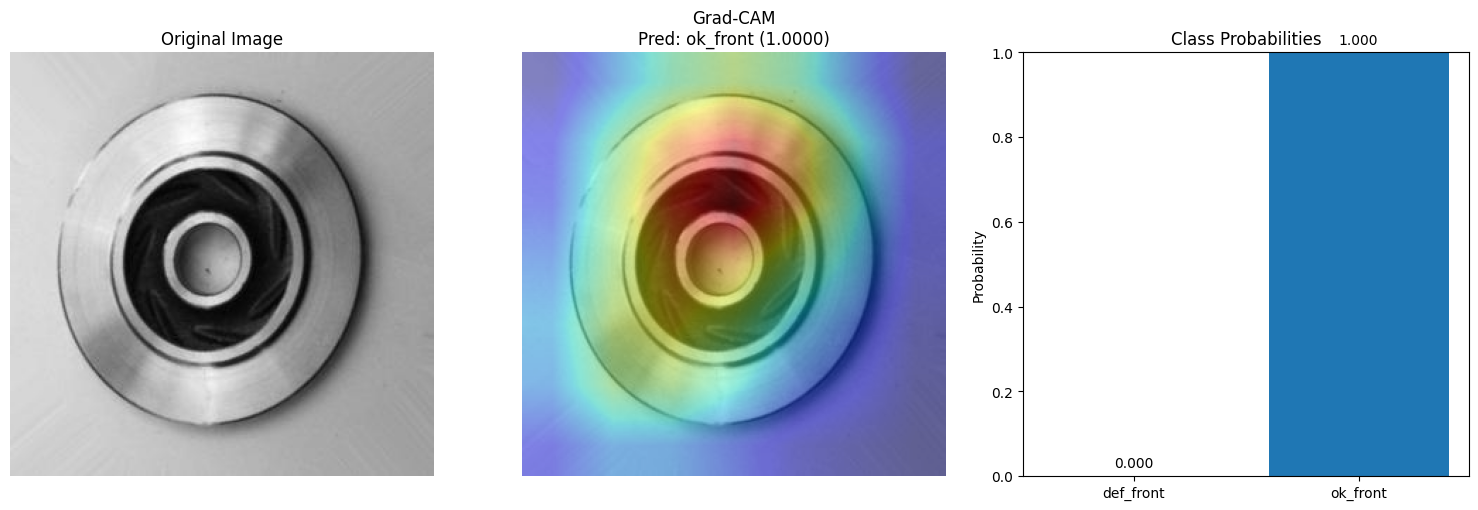

Grad-CAM concentration metrics:
  Active area ratio (CAM >= 0.7): 0.1192
  Entropy: 11.1583


In [30]:
ok_folder = "/kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test/ok_front"
ok_image = os.path.join(ok_folder, os.listdir(ok_folder)[0])

probs_ok, cam_ok, metrics_ok = show_gradcam_with_metrics(
    image_path=ok_image,
    model=resnet_model,
    transform=eval_transform_resnet,
    class_names=class_names,
    device=device,
    threshold=0.7
)

In [31]:
import pandas as pd

comparison_cam_df = pd.DataFrame([
    {
        "Image": "Defective sample",
        "Active area ratio": metrics_def["active_area_ratio"],
        "Entropy": metrics_def["entropy"]
    },
    {
        "Image": "Non-defective sample",
        "Active area ratio": metrics_ok["active_area_ratio"],
        "Entropy": metrics_ok["entropy"]
    }
])

comparison_cam_df = comparison_cam_df.round(4)
print(comparison_cam_df)

                  Image  Active area ratio  Entropy
0      Defective sample             0.1320  10.9279
1  Non-defective sample             0.1192  11.1583
